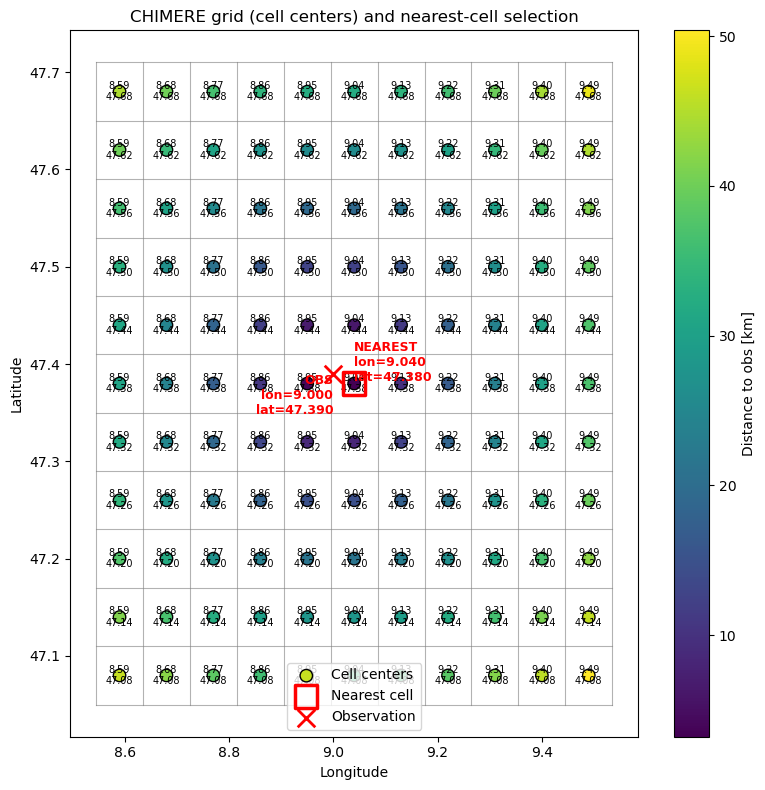

Observation:
  lon = 9.000000, lat = 47.390000

Nearest cell:
  indices (south_north, west_east) = (203, 52)  [xarray, 0-based]
  lon = 9.040000
  lat = 47.380000
  distance ≈ 3.204 km


In [7]:
#!/usr/bin/env python3
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT
# ============================================================
ncfile = "/mnt/mumbai_n3r6/25-12676_MIMESI/kAiros/out.2025121500_2025121600_ITA7.nc"   # <-- cambia con il tuo file
lat0 = 47.39               # osservazione
lon0 = 9.00

# ============================================================
# LOAD DATA
# ============================================================
ds = xr.open_dataset(ncfile)

lat = ds["lat"].values   # (south_north, west_east)
lon = ds["lon"].values

# ============================================================
# DISTANCE (same metric as DART/Fortran)
# ============================================================
coslat = np.cos(np.deg2rad(lat0))
dx = (lon - lon0) * 111.0 * coslat
dy = (lat - lat0) * 111.0
dist2 = dx**2 + dy**2

jmin, imin = np.unravel_index(np.argmin(dist2), dist2.shape)

# ============================================================
# SUBDOMAIN AROUND NEAREST CELL
# ============================================================
dj, di = 5, 5
j0, i0 = jmin, imin

lat_sub = lat[j0-dj:j0+dj+1, i0-di:i0+di+1]
lon_sub = lon[j0-dj:j0+dj+1, i0-di:i0+di+1]
dist_sub = dist2[j0-dj:j0+dj+1, i0-di:i0+di+1]

# ============================================================
# UTIL: centers -> edges (for visualization only)
# ============================================================
def centers_to_edges_1d(x):
    edges = np.zeros(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - (edges[1] - x[0])
    edges[-1] = x[-1] + (x[-1] - edges[-2])
    return edges

lat_centers = lat_sub[:, 0]
lon_centers = lon_sub[0, :]

lat_edges = centers_to_edges_1d(lat_centers)
lon_edges = centers_to_edges_1d(lon_centers)

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(8, 8))

# --- draw grid (cell edges)
for x in lon_edges:
    plt.plot(
        [x, x],
        [lat_edges[0], lat_edges[-1]],
        color="gray",
        linewidth=0.8,
        alpha=0.6
    )

for y in lat_edges:
    plt.plot(
        [lon_edges[0], lon_edges[-1]],
        [y, y],
        color="gray",
        linewidth=0.8,
        alpha=0.6
    )

# --- draw cell centers
sc = plt.scatter(
    lon_sub,
    lat_sub,
    c=np.sqrt(dist_sub),
    cmap="viridis",
    s=80,
    edgecolor="k",
    zorder=3,
    label="Cell centers"
)

# --- annotate each center (lon/lat)
for jj in range(lat_sub.shape[0]):
    for ii in range(lat_sub.shape[1]):
        plt.text(
            lon_sub[jj, ii],
            lat_sub[jj, ii],
            f"{lon_sub[jj,ii]:.2f}\n{lat_sub[jj,ii]:.2f}",
            fontsize=7,
            ha="center",
            va="center",
            zorder=4
        )

# --- nearest cell
plt.scatter(
    lon[jmin, imin],
    lat[jmin, imin],
    s=260,
    marker="s",
    facecolor="none",
    edgecolor="red",
    linewidth=2.5,
    zorder=5,
    label="Nearest cell"
)

plt.text(
    lon[jmin, imin],
    lat[jmin, imin],
    f"NEAREST\nlon={lon[jmin,imin]:.3f}\nlat={lat[jmin,imin]:.3f}",
    fontsize=9,
    color="red",
    ha="left",
    va="bottom",
    weight="bold",
    zorder=6
)

# --- observation
plt.scatter(
    lon0,
    lat0,
    c="red",
    marker="x",
    s=160,
    linewidth=2,
    zorder=6,
    label="Observation"
)

plt.text(
    lon0,
    lat0,
    f"OBS\nlon={lon0:.3f}\nlat={lat0:.3f}",
    fontsize=9,
    color="red",
    ha="right",
    va="top",
    weight="bold",
    zorder=6
)

plt.colorbar(sc, label="Distance to obs [km]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("CHIMERE grid (cell centers) and nearest-cell selection")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# PRINT NUMBERS (for log comparison)
# ============================================================
print("Observation:")
print(f"  lon = {lon0:.6f}, lat = {lat0:.6f}\n")

print("Nearest cell:")
print(f"  indices (south_north, west_east) = ({jmin}, {imin})  [xarray, 0-based]")
print(f"  lon = {lon[jmin,imin]:.6f}")
print(f"  lat = {lat[jmin,imin]:.6f}")
print(f"  distance ≈ {np.sqrt(dist2[jmin,imin]):.3f} km")
